In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os

print("EDA environment ready..")

EDA environment ready..


In [32]:
from src.database.connection import engine

print("Database connection module loaded.")

print("PostgreSQL engine created.")

Database connection module loaded.
PostgreSQL engine created.


In [33]:
# Test that the notebook can actually communicate with PostgreSQL.
with engine.connect() as connection:
    result = connection.exec_driver_sql("SELECT version();")
    print(result.fetchone()[0])

PostgreSQL 18.4 (Debian 18.4-1.pgdg13+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 14.2.0-19) 14.2.0, 64-bit


In [34]:
invoices = pd.read_sql(
 """
   SELECT *
   FROM invoices
   ORDER BY invoice_date;
 """,
    engine
)


print(f"Loaded{len(invoices):,} invoices.")

invoices.head()

Loaded1,000 invoices.


,id,invoice_number,supplier_id,customer_id,invoice_date,currency,subtotal,discount,tax_rate,tax_amount,total,created_at
0,1ba9827b-eab4-4f72-97cb-0b98fde0c2ef,INV-000542,9dadbda9-f8a5-42df-982e-093a2c5fa025,b526f849-25d9-4ac9-b574-6ee6552a638f,2025-08-12 23:10:22.161183+00:00,GBP,2648.75,0.00,13.48,357.14,3005.89,2026-08-12 23:10:21.552532+00:00
1,032e93f6-1961-4d33-86c9-fb988439cab0,INV-000770,9d759c2c-a4ec-4749-8e4d-e35706f96c52,b8a00e4d-e0c9-48bf-a25e-94837cb27528,2025-08-12 23:10:22.436519+00:00,GBP,3440.42,0.00,19.87,683.76,4124.18,2026-08-12 23:10:21.552532+00:00
2,6531c703-6acc-43d5-b2b6-c8bbda798bdf,INV-000876,70fac672-8d03-46f5-89a5-057287c9d942,45c8c038-e1e0-4d8a-806b-cfabea701c1e,2025-08-12 23:10:22.561622+00:00,GBP,2183.90,0.00,20.00,436.78,2620.68,2026-08-12 23:10:21.552532+00:00
3,76dfbffa-db13-4ef9-851a-e9d5815c93e2,INV-000489,fc22b204-de19-42ef-8b36-aa49210915df,fc812513-6ffb-4832-9336-79dcdff7a5b0,2025-08-13 23:10:22.100434+00:00,GBP,2242.66,83.82,20.78,448.53,2607.37,2026-08-12 23:10:21.552532+00:00
4,93a93035-4af3-41b0-a175-323be0fc313b,INV-000003,f47a6c1d-291f-4462-a509-ad3ac22206a5,4112c85a-156a-466a-a29b-b8e7d7e405d7,2025-08-14 23:10:21.561137+00:00,GBP,1277.80,0.00,20.00,255.56,1533.36,2026-08-12 23:10:21.552532+00:00


In [35]:
invoice_items = pd.read_sql(
    """
    SELECT *
    FROM invoice_items;
    """,
    engine,
)

print(f"Loaded {len(invoice_items):,} invoice items.")

# Display the first five items.
invoice_items.head()

Loaded 4,534 invoice items.


,id,invoice_id,product_id,quantity,unit_price,discount,tax_rate,tax_amount,subtotal,total
0,28f5edfe-2a7c-4caf-8df5-cb897e197c3c,deeebb15-597f-4264-8a1f-d18dec103014,55046e6b-3496-401c-bab4-7fe602346687,4.499,54.90,0.0,20.0,49.40,247.00,296.39
1,4d774d9b-80b7-4f22-91e0-4ca23b2606dd,deeebb15-597f-4264-8a1f-d18dec103014,1a9f7b6c-cac8-478b-a215-abb3ad887d8a,19.000,46.07,0.0,20.0,175.07,875.33,1050.40
2,9c41dafa-cb1f-4fc2-bd1b-c0160d8cdeb2,deeebb15-597f-4264-8a1f-d18dec103014,2cb87bde-5628-457f-bb49-a098349eb482,10.000,54.44,0.0,20.0,108.88,544.40,653.28
3,5eef64bd-4940-4606-8b14-6d9808aedb72,deeebb15-597f-4264-8a1f-d18dec103014,645c2a59-cf27-4ada-a410-eddbcfb94a34,16.000,29.61,0.0,20.0,94.75,473.76,568.51
4,042b6ae3-038c-4006-9af9-0acaaa62a0eb,deeebb15-597f-4264-8a1f-d18dec103014,4d56cd80-4aaf-457f-9f44-627ba201d050,11.000,45.59,0.0,20.0,100.30,501.49,601.79


In [36]:
anomaly_labels = pd.read_sql(
"""
  SELECT *
  FROM anomaly_labels;
""",
    engine
)

print(f"Loaded {len(anomaly_labels):,} anomaly labels")

anomaly_labels.head()

Loaded 20 anomaly labels


,id,invoice_id,invoice_number,anomaly_type,is_anomaly,created_at
0,aba1f872-df96-45e9-ba2a-96df0fd1d2f5,45758179-9a09-4651-8324-0d63ce728e66,INV-000026,quantity_spike,True,2026-08-12 23:10:21.552532+00:00
1,4de14aaa-59e7-4b0c-b23e-b5de8383e75b,e331248c-c5b9-456f-bb8a-2d3456f20e9a,INV-000031,price_spike,True,2026-08-12 23:10:21.552532+00:00
2,ef0d31af-bd96-49fa-8118-d91caae896b4,52cb4eb7-adcb-4754-8eed-675aaa8b3abe,INV-000033,price_spike,True,2026-08-12 23:10:21.552532+00:00
3,6f344d5c-4c91-42cd-9de9-8be6cc8da429,83db7adb-ccfa-40c1-a76b-04d9ac475356,INV-000090,price_spike,True,2026-08-12 23:10:21.552532+00:00
4,05834e5f-d05e-4322-9411-ce169a048fab,0083d1ff-65ac-4f2c-80ef-0a512b11da94,INV-000096,price_spike,True,2026-08-12 23:10:21.552532+00:00


In [37]:
print("Invoices:", invoices.shape)
print("Invoice items:", invoice_items.shape)
print("Anomaly labels:", anomaly_labels.shape)

Invoices: (1000, 12)
Invoice items: (4534, 10)
Anomaly labels: (20, 6)


In [38]:
invoices.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype              
---  ------          --------------  -----              
 0   id              1000 non-null   object             
 1   invoice_number  1000 non-null   str                
 2   supplier_id     1000 non-null   object             
 3   customer_id     1000 non-null   object             
 4   invoice_date    1000 non-null   datetime64[us, UTC]
 5   currency        1000 non-null   str                
 6   subtotal        1000 non-null   float64            
 7   discount        1000 non-null   float64            
 8   tax_rate        1000 non-null   float64            
 9   tax_amount      1000 non-null   float64            
 10  total           1000 non-null   float64            
 11  created_at      1000 non-null   datetime64[us, UTC]
dtypes: datetime64[us, UTC](2), float64(5), object(3), str(2)
memory usage: 93.9+ KB


In [40]:
# Find Missing Values
missing = (
    invoices.isna()
    .sum()
    .sort_values(ascending=False)
)

missing

id                0
invoice_number    0
supplier_id       0
customer_id       0
invoice_date      0
currency          0
subtotal          0
discount          0
tax_rate          0
tax_amount        0
total             0
created_at        0
dtype: int64

In [41]:
# Missing Values in Invoice Items
invoice_items.isna().sum().sort_values(ascending=False)

id            0
invoice_id    0
product_id    0
quantity      0
unit_price    0
discount      0
tax_rate      0
tax_amount    0
subtotal      0
total         0
dtype: int64

In [42]:
# Statistical Summary for Invoice of numerical features
invoices[[
    "subtotal",
    "discount",
    "tax_rate",
    "tax_amount",
    "total"
]].describe()

,subtotal,discount,tax_rate,tax_amount,total
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2481.780400,32.782740,16.548180,412.670340,2861.667990
std,1738.487048,87.357838,5.138458,317.508865,2012.077628
min,0.890000,0.000000,0.000000,0.000000,1.070000
25%,1104.977500,0.000000,14.450000,166.762500,1256.222500
50%,2246.650000,0.000000,18.895000,354.475000,2583.690000
75%,3463.457500,0.000000,20.000000,603.440000,4006.897500
max,10481.390000,937.730000,22.220000,2051.340000,11595.000000


In [43]:
anomaly_labels["anomaly_type"].value_counts()

anomaly_type
price_spike       9
quantity_spike    8
tax_error         3
Name: count, dtype: int64

In [46]:
item_features = (
    invoice_items
    .groupby("invoice_id")
    .agg(
        item_count=("id", "count"),
        total_quantity=("quantity", "sum"),
        avg_quantity=("quantity", "mean"),
        max_quantity=("quantity", "max"),
        avg_unit_price=("unit_price", "mean"),
        max_unit_price=("unit_price", "max"),
        avg_tax_rate=("tax_rate", "mean"),
        max_tax_rate=("tax_rate", "max"),
    )
    .reset_index()
)

item_features.head()

,invoice_id,item_count,total_quantity,avg_quantity,max_quantity,avg_unit_price,max_unit_price,avg_tax_rate,max_tax_rate
0,0038f088-8b18-43ce-a308-27e1ff0e2bee,3,36.201,12.067000,21.201,28.340000,62.36,13.333333,20.0
1,0083d1ff-65ac-4f2c-80ef-0a512b11da94,3,43.654,14.551333,27.000,51.483333,68.67,20.000000,20.0
2,00b5b271-93f1-42d0-8272-2f969c9efe21,4,54.324,13.581000,26.324,33.420000,40.28,16.250000,20.0
3,00cd030e-d51e-4cbe-bc0b-325c8422a4e4,3,39.000,13.000000,14.000,24.466667,40.14,15.000000,20.0
4,00ebc2f0-ea04-4776-94da-fd2ce47a9f2c,8,106.017,13.252125,36.829,36.052500,64.49,13.125000,20.0


In [53]:
analysis_df = invoices.merge(
    item_features,
    left_on="id",
    right_on="invoice_id",
    how="left"
)


analysis_df = analysis_df.merge(
    anomaly_labels[
       [     "invoice_id",
            "anomaly_type",
            "is_anomaly",]
    ],
    on="invoice_id",
    how="left"
)


analysis_df["is_anomaly"] = (
    analysis_df["is_anomaly"]
    .fillna(False)
    .astype(bool)
)


analysis_df["anomaly_type"] = (
    analysis_df["anomaly_type"]
    .fillna("normal")
)


print(analysis_df)

                                       id invoice_number  \
0    1ba9827b-eab4-4f72-97cb-0b98fde0c2ef     INV-000542   
1    032e93f6-1961-4d33-86c9-fb988439cab0     INV-000770   
2    6531c703-6acc-43d5-b2b6-c8bbda798bdf     INV-000876   
3    76dfbffa-db13-4ef9-851a-e9d5815c93e2     INV-000489   
4    93a93035-4af3-41b0-a175-323be0fc313b     INV-000003   
..                                    ...            ...   
995  a4a998ae-d396-4f0a-a84e-ff8feb86313e     INV-000264   
996  ffb16412-fef8-46e0-9025-fa565ac764ab     INV-000634   
997  df572808-35b7-4fda-8d6b-bda088b066b7     INV-000685   
998  6d123e4a-e4fc-4c31-8ec8-2e302ebe7c92     INV-000837   
999  3a9b4d6d-a363-43d1-901d-32314c68545a     INV-000082   

                              supplier_id  \
0    9dadbda9-f8a5-42df-982e-093a2c5fa025   
1    9d759c2c-a4ec-4749-8e4d-e35706f96c52   
2    70fac672-8d03-46f5-89a5-057287c9d942   
3    fc22b204-de19-42ef-8b36-aa49210915df   
4    f47a6c1d-291f-4462-a509-ad3ac22206a5   
..       

In [54]:

analysis_df[
    [
        "subtotal",
        "tax_rate",
        "item_count",
        "total_quantity",
        "avg_unit_price",
        "max_unit_price",
        "is_anomaly",
        "anomaly_type",
    ]
].head(10)

,subtotal,tax_rate,item_count,total_quantity,avg_unit_price,max_unit_price,is_anomaly,anomaly_type
0,2648.75,13.48,8,164.354,19.121250,55.77,False,normal
1,3440.42,19.87,7,108.611,27.464286,63.57,False,normal
2,2183.90,20.00,6,66.977,33.515000,61.26,False,normal
3,2242.66,20.78,4,79.716,27.080000,57.62,False,normal
4,1277.80,20.00,3,47.420,35.033333,50.62,False,normal
5,2232.17,20.00,4,65.164,21.245000,40.86,False,normal
6,4325.75,20.00,8,132.880,33.368750,61.03,False,normal
7,2561.78,12.71,8,96.572,29.615000,54.63,False,normal
8,3222.26,4.67,5,84.000,32.018000,55.65,False,normal
9,4408.45,17.65,8,207.313,20.286250,46.35,False,normal


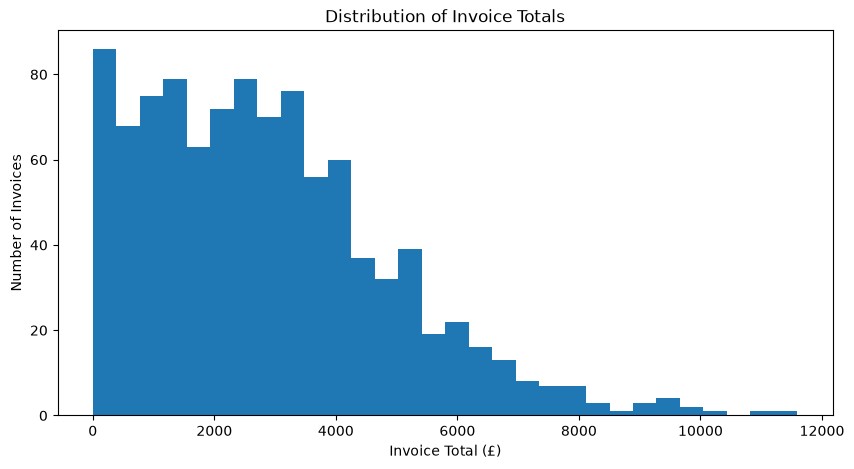

In [60]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10, 5))


plt.hist(invoices["total"], bins=30)

plt.title("Distribution of Invoice Totals")
plt.xlabel("Invoice Total (£)")
plt.ylabel("Number of Invoices")

plt.show()


## What does the distributions of invoice total looks like?
The invoices are `right-skewed`. Majority are relatively low to medium totals, while only small portion of invoices have very high totals. Approximately `86` invoices fall in £0–£388 range while only a `few invoices`are in the £10,000–£12,000 range.

## ML Implications
However, a high invoice total should not be marked as anomaly by default. A high total invoice can be legitimate based on different categories, such as - supplier, customer, quantity, product, pricing, historical behaviour.

Therefore, invoice `total` should be used as one feature among several. The anomaly detection model should consider the context and relationships between multiple features.


In [63]:
anomaly_mask = analysis_df["is_anomaly"]

normal_invoices = analysis_df[~anomaly_mask]
anomalous_invoices = analysis_df[anomaly_mask]

print("Normal invoices:", len(normal_invoices))
print("Anomalous invoices:", len(anomalous_invoices))

Normal invoices: 980
Anomalous invoices: 20


In [64]:
# compare avg invoice total and normal anomalous invoice total

comparison = pd.DataFrame({
    "Normal": [normal_invoices["total"].mean()],
    "Anomaly": [anomalous_invoices["total"].mean()]
})

comparison

,Normal,Anomaly
0,2807.297969,5525.799


## Which invoice-level numerical features differ between normal and anomalous invoices?

Before building an ML model, we need to understand whether known anomalies exhibit different numerical patterns from normal invoices.

We will compare the following features:

- `subtotal` — total value of invoice items before tax and after discounts.
- `discount` — discount applied to the invoice.
- `tax_rate` — tax percentage applied.
- `tax_amount` — monetary amount of tax.
- `total` — final invoice amount including tax.

The goal is not to define fixed anomaly rules, but to identify potentially useful features for the ML model.

In [68]:
invoice_features = [
    "subtotal",
    "discount",
    "tax_rate",
    "tax_amount",
    "total",
]


feature_comparison = (
    analysis_df
    .groupby("is_anomaly")[invoice_features]
    .mean()
    .T
)

feature_comparison.columns = [
    "Normal",
    "Anomaly",
]

# Display the comparison.
feature_comparison

,Normal,Anomaly
subtotal,2436.571112,4697.0355
discount,32.121827,65.1675
tax_rate,16.496276,19.0915
tax_amount,402.848694,893.9310
total,2807.297969,5525.7990


## Finding: Invoice-level numerical features

The anomalous invoices have higher average values across all numerical features.

The largest differences are observed in `subtotal`, `tax_amount`, and `total`. The average invoice total for anomalous invoices (£5,525.80) is almost twice that of normal invoices (£2,807.30).

But, this alone does not prove that high values are anomalous. Our synthetic anomalies include price and quantity spikes, which naturally increase invoice totals.

We therefore need to examine the distribution and overlap of normal and anomalous invoices before deciding whether these features are useful for anomaly detection.

## ML Implication

`subtotal`, `tax_amount`, and `total` appear potentially useful as model features, but they should not be used as standalone anomaly rules.

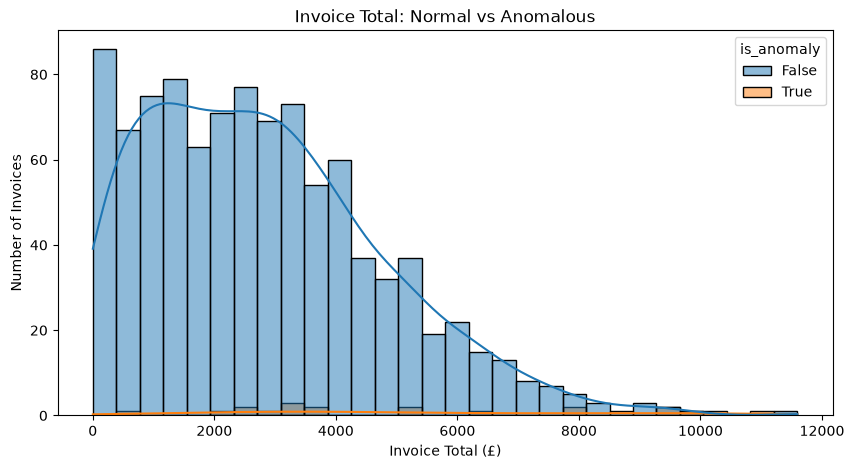

In [69]:
plt.figure(figsize=(10, 5))


sns.histplot(
    data=analysis_df,
    x="total",
    hue="is_anomaly",
    bins=30,
    kde=True
)


plt.title("Invoice Total: Normal vs Anomalous")
plt.xlabel("Invoice Total (£)")
plt.ylabel("Number of Invoices")

plt.show()

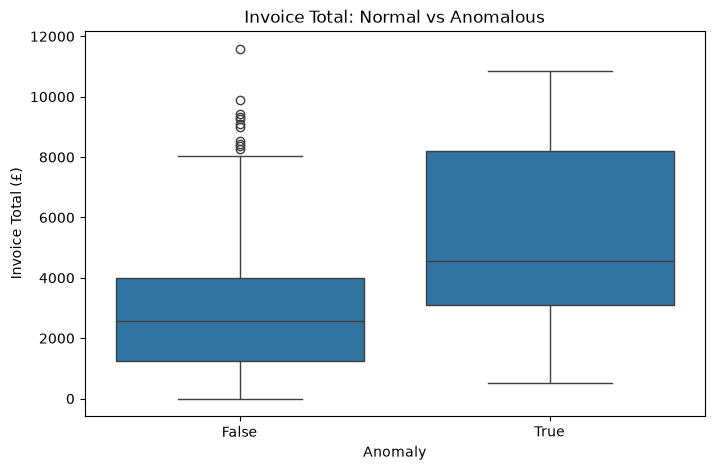

In [70]:
# Compare the distribution of invoice totals between
# normal and anomalous invoices.

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=analysis_df,
    x="is_anomaly",
    y="total",
)

plt.title("Invoice Total: Normal vs Anomalous")
plt.xlabel("Anomaly")
plt.ylabel("Invoice Total (£)")

plt.show()

## Findings: Invoice Total Distribution
The box plot shows that anomalous invoices generally have higher total values than normal invoices. However, several normal invoices also appear as high-value outliers, with totals reaching approximately £8,000–£10,000.

This confirms that a high invoice total alone is not sufficient to determine whether an invoice is anomalous.


### ML Implication

The model should consider invoice totals together with contextual features such as supplier, customer, product, quantity, unit price, and historical purchasing behaviour.

This is particularly important because a value that is unusual across the entire dataset may still be normal for a specific supplier-customer relationship.

## How do different anomaly types affect invoice totals?

Our synthetic dataset contains three known anomaly types:

- `price_spike`
- `quantity_spike`
- `tax_error`

We want to determine whether these anomaly types produce any different numerical patterns.

In [71]:
anomaly_type_summary = (
    analysis_df[analysis_df["is_anomaly"]]
    .groupby("anomaly_type")["total"]
    .agg(["count", "mean", "min", "max"])
    .round(2)
)

anomaly_type_summary

,count,mean,min,max
anomaly_type,,,,
price_spike,9,4818.41,2540.51,9462.68
quantity_spike,8,7419.51,2015.52,10841.82
tax_error,3,2598.06,502.90,3849.41
